# Epipolar geometry
A pinhole camera projects a 3D scene down to a 2D plane and thus loses the depth dimension. The solution to this problem is to use two cameras - i.e. stereo vision. If two cameras observe the same scene from offset positions, a point in the imageplane from one of the cameras will lie on a line in the imageplane of the other camera. In this exercise you will be drawing epipolar lines on a set of images to visualize where the two cameras are located in relation to each other in image coordinates.

As always, start by importing necessary libraries.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## Exercise 2.1
Use [SIFT](https://docs.opencv.org/4.7.0/d7/d60/classcv_1_1SIFT.html) to detect and compute features in both the left and right images and optionally visualize the keypoints.

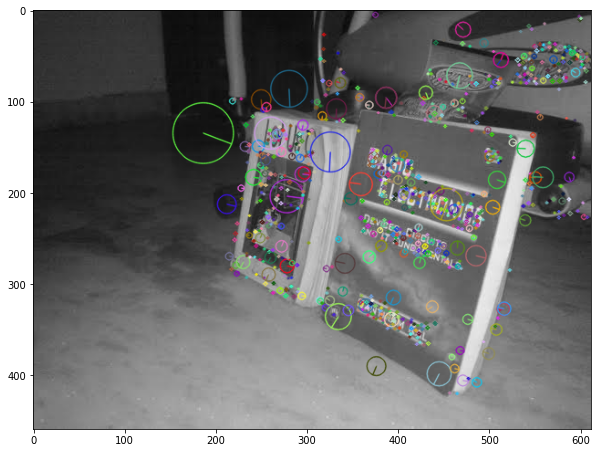

In [7]:
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 4/"
# Load images in grayscale (flag 0)
img1 = cv2.imread(path + "img_left.jpg", 0)
img2 = cv2.imread(path + "img_right.jpg", 0)

# Detect keypoints here
# We use SIFT (Scale-Invariant Feature Transform) because it is robust to scale and rotation changes.
# detectAndCompute returns:
# kp: list of KeyPoints (coordinates, size, angle, response, octave, class_id)
# des: descriptor numpy array of shape (Number of Keypoints, 128)
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Visualize the keypoints on the second image to verify detection
kp_img = cv2.drawKeypoints(img2, kp2, img2, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize = (10,10))
plt.imshow(kp_img)

## Exercise 2.2
The next step is to match the features in the two images. We can do that exactly like we did in previous exercises using [`cv2.BFMatcher`](https://docs.opencv.org/4.7.0/d3/da1/classcv_1_1BFMatcher.html). 

Fill in the missing code below by implementing `cv2.BFMatcher`. Store the matching results in a variable called `matches`.

In [8]:
# Implement bf matcher here
# BFMatcher (Brute Force Matcher) takes the descriptor of one feature in the first set
# and is matched with all other features in the second set using some distance calculation.
# Default distance for SIFT is Euclidean (L2-Norm).
bf = cv2.BFMatcher()
matches = bf.match(des1, des2)

# Sort them in the order of their distance (i.e. best matches first).
# Lower distance means the descriptors are more similar.
matches = sorted(matches, key = lambda x:x.distance)

The above gives us a list of best matches in proritized order. We can use the function [`findFundamentalMat`](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html#gae420abc34eaa03d0c6a67359609d8429) to compute the fundamental matrix using a number of the best keypoint matches.

In [9]:
# We limit the number of matches to the top 200 to speed up computation and reduce noise
nb_matches = 200

good = []
pts1 = []
pts2 = []

# Extract the coordinates of the matching keypoints
for m in matches[:nb_matches]:
    good.append(m)
    # queryIdx is the index in kp1 (left image), trainIdx is the index in kp2 (right image)
    pts1.append(kp1[m.queryIdx].pt)
    pts2.append(kp2[m.trainIdx].pt)

# Convert to numpy arrays of integers
pts1 = np.int32(pts1)
pts2 = np.int32(pts2)
    
# Implement findFundamentalMat here:
# cv2.findFundamentalMat(points1, points2, method)
# This calculates the Fundamental Matrix F, which encapsulates the epipolar geometry.
# For any point x in one image and x' in the other: x' * F * x = 0.
#
# Methods:
# cv2.FM_7POINT - 7-point algorithm
# cv2.FM_8POINT - 8-point algorithm
# cv2.FM_LMEDS - Least Median of Squares (robust to outliers)
# cv2.FM_RANSAC - RANSAC (robust to outliers, commonly used)
F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_LMEDS)

# We select only inlier points based on the mask returned by the algorithm
# The mask contains 0 for outliers and 1 for inliers.
pts1 = pts1[mask.ravel() == 1]
pts2 = pts2[mask.ravel() == 1]

In order to draw the epipolar lines, we can use the following function.

In [10]:
def drawlines(img1,img2,lines,pts1,pts2):
    ''' img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines '''
    r,c = img1.shape
    img1 = cv2.cvtColor(img1,cv2.COLOR_GRAY2BGR)
    img2 = cv2.cvtColor(img2,cv2.COLOR_GRAY2BGR)
    
    # Zip together the lines (equation parameters) and the points
    for r,pt1,pt2 in zip(lines,pts1,pts2):
        color = tuple(np.random.randint(0,255,3).tolist())
        
        # Calculate start and end points of the line on the image border
        # Line equation: ax + by + c = 0 => y = -(ax + c) / b
        # We calculate y for x=0 (left border) and x=c (right border)
        x0,y0 = map(int, [0, -r[2]/r[1] ])
        x1,y1 = map(int, [c, -(r[2]+r[0]*c)/r[1] ])
        
        img1 = cv2.line(img1, (x0,y0), (x1,y1), color,2)
        img1 = cv2.circle(img1,tuple(pt1),5,color,-1)
        img2 = cv2.circle(img2,tuple(pt2),5,color,-1)
    return img1,img2

## Exercise 2.3
We can then use the function [`computeCorrespondEpilines`](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html#ga19e3401c94c44b47c229be6e51d158b7), which uses the fundamental matrix and the matching keypoints.

Previously, we selected a number of the best keypoint matches. Try to decrease or increase this number and visuallise the result. What happens with the epipolar lines? Remember you have to compute the fundamental matrix again based on the new number of keypoints.

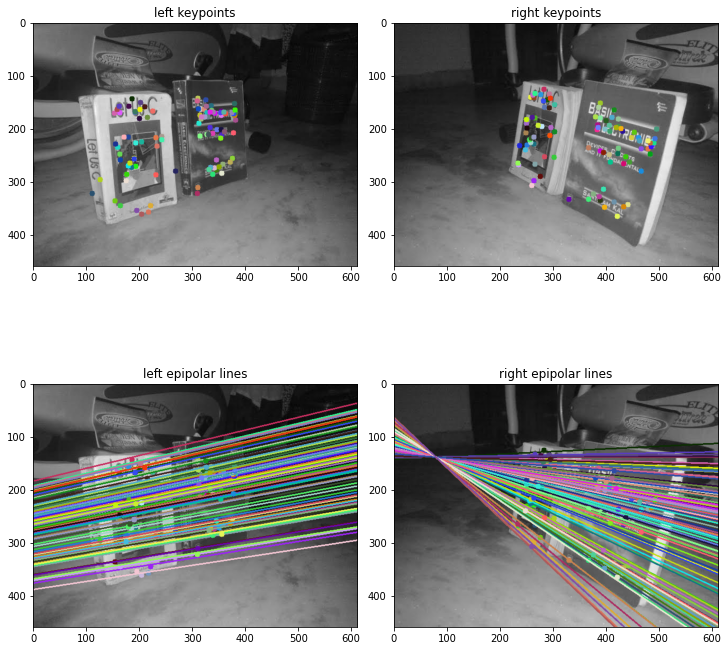

In [11]:
# Find epilines corresponding to points in right image (second image) and
# drawing its lines on left image.
# cv2.computeCorrespondEpilines(points, whichImage, F)
# whichImage=2 means the points are from the second image, and we want lines in the first image.
lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1, 1, 2), 2 ,F)
lines1 = lines1.reshape(-1, 3)
img5, img6 = drawlines(img1, img2, lines1, pts1, pts2)

# Find epilines corresponding to points in left image (first image) and
# drawing its lines on right image.
# whichImage=1 means the points are from the first image, and we want lines in the second image.
lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1, 1, 2), 1, F)
lines2 = lines2.reshape(-1, 3)
img3, img4 = drawlines(img2, img1, lines2, pts2, pts1)

fig, axs = plt.subplots(2, 2, constrained_layout=True, figsize=(10,10))
axs[0, 0].imshow(img4)
axs[0, 0].set_title('left keypoints')
axs[0, 1].imshow(img6)
axs[0, 1].set_title('right keypoints')
axs[1, 0].imshow(img5)
axs[1, 0].set_title('left epipolar lines')
axs[1, 1].imshow(img3)
axs[1, 1].set_title('right epipolar lines')
plt.show()

## Optional exercise
The downside of using bf matcher is that it doesn't scale well when the number of keypoints increase. Instead we could opt for using `Fast Library for Approximate Nearest Neighbors (flann)` by sacrificing some accuracy. The exercise is to replace bf match in the previous exercise with a [flann based matcher](https://docs.opencv.org/4.7.0/dc/de2/classcv_1_1FlannBasedMatcher.html) and compare the results.